# Jigsaw Image Reconstruction


This notebook contains the complete solution for reconstructing a 96×96 RGB image from 9 scrambled 28×28 RGB patches.  
The solution is implemented entirely in Keras/TensorFlow.


## Method summary

The model follows a reconstruction-only approach. It receives the 9 unordered cropped patches and directly predicts the original 96×96 image using MAE as the training objective.

The architecture has four main parts:

1. **Patch encoder:** the same convolutional encoder is applied to each patch.
2. **Patch interaction module:** a transformer compares the 9 patch tokens and learns their spatial relationships.
3. **Differentiable routing:** a Sinkhorn layer converts assignment logits into an approximate permutation matrix and routes patches to canvas positions.
4. **Inpainting decoder:** a small U-Net fills the missing borders and produces the final reconstructed image.

The final model has **4,203,013 total parameters** and **4,198,980 trainable parameters**, satisfying the 6M-parameter constraint. The saved run reached a test MAE of **0.035118** with a batch-wise test MAE standard deviation of **0.006101**.


In [1]:
import os
import random
import gdown
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import PyDataset

tf.config.optimizer.set_jit(False)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")

SEED = 1232426
BATCH_SIZE = 64
EPOCHS = 90

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Dataset and generator

The STL-10 unlabeled set contains 100,000 RGB images of size 96×96.  
The split used here is:

- 80,000 images for training
- 10,000 images for validation
- 10,000 images for testing

Each image is split into a 3×3 grid of 32×32 cells. From each cell, the central 28×28 crop is used as one puzzle patch. The target remains the original 96×96 image.


In [ ]:
#### Use this version of the get_stl10_memmap function for downloading directly from stanford website.

# def get_stl10_memmap():
#     path = tf.keras.utils.get_file('C:/Users/Diablo/Desktop/Deep Learning/Final/stl10_binary')
#     # tf.keras.utils.get_file(
#     #     'stl10_binary.tar.gz',
#     #     origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
#     #     extract=True
#     # )
#     base_dir = os.path.dirname(path)
#     filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')

#     # STL-10: 100,000 images, 3 channels, 96x96
#     # We use memmap to avoid loading the file into RAM
#     # Shape is (N, C, H, W) based on STL-10 binary format
#     shape = (100000, 3, 96, 96)
#     images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)
    
#     return images_mmap

def get_stl10_memmap(path="D:/University/Masters/Deep Learning/Final/stl10_binary/unlabeled_X.bin"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"STL-10 binary not found at: {path}")
    return np.memmap(path, dtype="uint8", mode="r", shape=(100000, 3, 96, 96))

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        try:
            super().__init__(**kwargs)
        except TypeError:
            super().__init__()

        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(images))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_size = len(batch_idx)

        X = np.zeros((batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((batch_size, 96, 96, 3), dtype="float32")

        margin = (self.patch_size - self.crop_size) // 2

        for i, image_idx in enumerate(batch_idx):
            image = self.images[image_idx].transpose(1, 2, 0).astype("float32") / 255.0
            Y[i] = image

            patches = []
            for row in range(3):
                for col in range(3):
                    y0 = row * self.patch_size
                    x0 = col * self.patch_size
                    patch = image[y0:y0 + self.patch_size, x0:x0 + self.patch_size]
                    patch = patch[margin:margin + self.crop_size, margin:margin + self.crop_size]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot, original_position in enumerate(order):
                X[i, slot] = patches[original_position]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


images = get_stl10_memmap()

# train_images = images[:80000]
# val_images = images[80000:90000]
test_images = images[90000:100000]

generator_options = dict(workers=4, use_multiprocessing=False, max_queue_size=16)

# train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, shuffle=True, **generator_options)
# val_generator = PatchGenerator(val_images, batch_size=BATCH_SIZE, shuffle=False, **generator_options)
test_generator = PatchGenerator(test_images, batch_size=BATCH_SIZE, shuffle=False, **generator_options)

# print("Train images:", len(train_images))
# print("Validation images:", len(val_images))
print("Test images:", len(test_images))


Test images: 10000


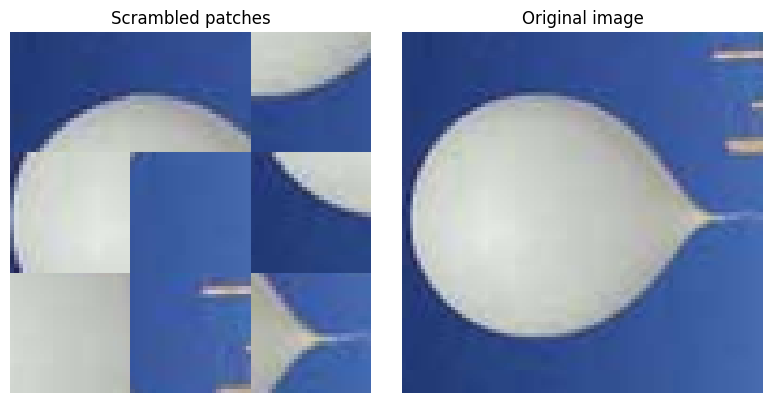

In [6]:
def make_puzzle_canvas(patches):
    canvas = np.ones((84, 84, 3), dtype="float32")
    patch_id = 0

    for row in range(3):
        for col in range(3):
            y0 = row * 28
            x0 = col * 28
            canvas[y0:y0 + 28, x0:x0 + 28] = patches[patch_id]
            patch_id += 1

    return canvas


def show_input_example(generator):
    X, Y = generator[np.random.randint(len(generator))]
    idx = np.random.randint(len(X))

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(np.clip(make_puzzle_canvas(X[idx]), 0, 1))
    plt.title("Scrambled patches")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.clip(Y[idx], 0, 1))
    plt.title("Original image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_input_example(test_generator)


## Model definition

The architecture is composed of two main parts. The first part focuses on understanding the content of each patch and estimating its correct position. Each patch is processed independently using shared convolutional layers through TimeDistributed operations. This allows the model to extract local visual features from all nine patches using the same encoder. After convolutional feature extraction, each patch is represented by a compact token built from global average pooling, global max pooling, and a learned spatial feature map. The pooled features summarize the general visual content of the patch, while the spatial map preserves information about where important details are located inside the patch, especially around the borders. This is important because the model must learn which patches are visually compatible with each other.

The patch tokens are then passed through a Transformer-based interaction module. The attention layers allow the nine patches to compare their features with each other and learn relationships between them. This helps the model reason about possible neighboring patches and global image structure rather than treating each patch independently. After this interaction stage, a dense layer predicts assignment scores between input patches and the nine possible grid positions.

To convert these assignment scores into a valid ordering, the model uses a Sinkhorn layer. This layer produces a soft permutation matrix during training, which keeps the routing operation differentiable and allows gradients to flow through the ordering mechanism. During inference, the soft assignment is converted into a hard assignment by selecting the most likely position for each patch. In this way, the model learns to reorder the shuffled patches without requiring explicit permutation supervision.

After the estimated ordering is obtained, the patches are routed into their predicted grid cells. Since each patch is 28 × 28 while the original grid cells are 32 × 32, the assembled image contains missing border regions between and around the patches. For this reason, the model does not stop after patch ordering. Instead, it builds a partially known 96 × 96 canvas and a corresponding mask that indicates which pixels are already available and which pixels must be reconstructed.

The second part of the architecture is an inpainting network based on a U-Net structure. The U-Net receives the partially assembled image, the mask, and a low-resolution hint image. Its role is to reconstruct the missing pixels, especially the borders and seams between neighboring patches. The final output is obtained by combining the known pixels from the assembled patches with the generated pixels from the inpainting network. This ensures that the model preserves the visible patch content while only filling the missing regions where necessary.

The model is trained end-to-end using Mean Absolute Error (MAE) between the reconstructed image and the original image. This means that both the implicit patch ordering module and the inpainting module are optimized together through the same reconstruction objective. The final architecture contains approximately 4.2 million parameters, remaining below the 6 million parameter limit while still combining convolutional feature extraction, attention-based patch reasoning, differentiable patch routing, and image inpainting in a single model.


In [7]:
@tf.keras.utils.register_keras_serializable(package="Jig5")
class SinkhornLayer(layers.Layer):
    def __init__(self, iterations=20, temperature=1.0, **kwargs):
        super().__init__(**kwargs)
        self.iterations = iterations
        self.temperature = float(temperature)

    def build(self, input_shape):
        self.tau = self.add_weight(
            name="tau",
            shape=(),
            trainable=False,
            initializer=tf.keras.initializers.Constant(self.temperature),
            dtype="float32",
        )
        super().build(input_shape)

    def call(self, logits, training=None):
        x = tf.cast(logits, tf.float32) / self.tau
        x = tf.nn.softmax(x, axis=-1)

        for _ in range(self.iterations):
            x = x / (tf.reduce_sum(x, axis=-1, keepdims=True) + 1e-8)
            x = x / (tf.reduce_sum(x, axis=-2, keepdims=True) + 1e-8)

        if training:
            return x

        return tf.one_hot(tf.argmax(x, axis=-1), depth=9, dtype=tf.float32)

    def get_config(self):
        config = super().get_config()
        config.update({"iterations": self.iterations, "temperature": self.temperature})
        return config


@tf.keras.utils.register_keras_serializable(package="Jig5")
class AssembleOcc(layers.Layer):
    def __init__(self, drop_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = drop_rate

    def call(self, inputs, training=None):
        ordered, occupancy = inputs

        ordered = tf.cast(ordered, tf.float32)
        occupancy = tf.cast(occupancy, tf.float32)

        cells = ordered / tf.maximum(occupancy, 1.0)[:, :, None, None, None]
        mask = tf.minimum(occupancy, 1.0)

        if training and self.drop_rate > 0:
            keep = tf.cast(tf.random.uniform((tf.shape(mask)[0], 9)) > self.drop_rate, tf.float32)
            cells = cells * keep[:, :, None, None, None]
            mask = mask * keep

        cell_mask = mask[:, :, None, None, None] * tf.ones((1, 1, 28, 28, 1), dtype=tf.float32)

        cells = tf.pad(cells, [[0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])
        cell_mask = tf.pad(cell_mask, [[0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])

        return [self._tile(cells, 3), self._tile(cell_mask, 1)]

    def _tile(self, x, channels):
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, (batch_size, 3, 3, 32, 32, channels))
        x = tf.transpose(x, (0, 1, 3, 2, 4, 5))
        return tf.reshape(x, (batch_size, 96, 96, channels))

    def compute_output_shape(self, input_shape):
        return [(input_shape[0][0], 96, 96, 3), (input_shape[0][0], 96, 96, 1)]

    def get_config(self):
        config = super().get_config()
        config.update({"drop_rate": self.drop_rate})
        return config

def create_hole_hint(values):
    known_image, known_mask = values

    known_image = tf.cast(known_image, tf.float32)
    known_mask = tf.cast(known_mask, tf.float32)

    small_image = tf.image.resize(known_image, (48, 48))
    small_mask = tf.image.resize(known_mask, (48, 48))

    hint = small_image / tf.maximum(small_mask, 0.1)
    hint = tf.image.resize(hint, (96, 96))

    return tf.clip_by_value(hint, 0.0, 1.0)

def jigsaw_model(embed=192, transformer_layers=5, heads=8, spatial_channels=8, cell_drop=0.0):
    inputs = layers.Input((9, 28, 28, 3), name="scrambled_patches")

    # Time-distributed Patch Encoder
    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", use_bias=False), name="enc1a")(inputs)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc1a_bn")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="enc1a_r")(x)

    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", use_bias=False), name="enc1b")(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc1b_bn")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="enc1b_r")(x)

    x = layers.TimeDistributed(layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False), name="enc2a")(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc2a_bn")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="enc2a_r")(x)

    x = layers.TimeDistributed(layers.Conv2D(64, 3, padding="same", use_bias=False), name="enc2b")(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc2b_bn")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="enc2b_r")(x)

    x = layers.TimeDistributed(layers.Conv2D(128, 3, strides=2, padding="same", use_bias=False), name="enc3a")(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc3a_bn")(x)
    x = layers.TimeDistributed(layers.Activation("relu"), name="enc3a_r")(x)

    x = layers.TimeDistributed(layers.Conv2D(128, 3, padding="same", use_bias=False), name="enc3b")(x)
    x = layers.TimeDistributed(layers.BatchNormalization(), name="enc3b_bn")(x)
    features = layers.TimeDistributed(layers.Activation("relu"), name="enc3b_r")(x)

    # Sequence Feature Pooling
    gap = layers.TimeDistributed(layers.GlobalAveragePooling2D(), name="gap")(features)
    gmp = layers.TimeDistributed(layers.GlobalMaxPooling2D(), name="gmp")(features)

    spatial = layers.TimeDistributed(layers.Conv2D(spatial_channels, 1, activation="relu"), name="spat_proj")(features)
    spatial = layers.TimeDistributed(layers.Flatten(), name="spat_flat")(spatial)

    tokens = layers.Concatenate(name="patch_feat")([gap, gmp, spatial])
    tokens = layers.Dense(embed, name="embed")(tokens)

    # Transformer Blocks
    for i in range(transformer_layers):
        x = layers.LayerNormalization(name=f"ln_a{i}")(tokens)
        attn = layers.MultiHeadAttention(
            num_heads=heads,
            key_dim=embed // heads,
            dropout=0.05,
            name=f"mha{i}",
        )(x, x)

        tokens = layers.Add(name=f"add_a{i}")([tokens, attn])

        x = layers.LayerNormalization(name=f"ln_f{i}")(tokens)
        x = layers.Dense(embed * 2, activation="relu", name=f"ff{i}_1")(x)
        x = layers.Dense(embed, name=f"ff{i}_2")(x)

        tokens = layers.Add(name=f"add_f{i}")([tokens, x])

    tokens = layers.LayerNormalization(name="ln_out")(tokens)

    # Permutation Routing
    logits = layers.Dense(9, name="assign_logits", dtype="float32")(tokens)
    permutation = SinkhornLayer(name="sinkhorn")(logits)

    flat_patches = layers.Reshape((9, 28 * 28 * 3), name="flat")(inputs)

    routed = layers.Lambda(
        lambda values: tf.matmul(
            tf.transpose(tf.cast(values[0], tf.float32), (0, 2, 1)),
            tf.cast(values[1], tf.float32),
        ),
        name="route",
    )([permutation, flat_patches])

    ordered = layers.Reshape((9, 28, 28, 3), name="ordered")(routed)
    occupancy = layers.Lambda(lambda p: tf.reduce_sum(tf.cast(p, tf.float32), axis=1), name="occupancy")(permutation)

    known, mask = AssembleOcc(drop_rate=cell_drop, name="assemble")([ordered, occupancy])

    hint = layers.Lambda(create_hole_hint, name="hole_hint")([known, mask])

    # UNet Inpainter Input Concatenation
    x = layers.Concatenate(name="inpaint_in")([known, mask, hint])

    # --- UNet Encoder ---
    # Block u_e1
    x = layers.Conv2D(40, 3, padding="same", use_bias=False, name="u_e1_c1")(x)
    x = layers.BatchNormalization(name="u_e1_b1")(x)
    x = layers.Activation("relu", name="u_e1_r1")(x)
    x = layers.Conv2D(40, 3, padding="same", use_bias=False, name="u_e1_c2")(x)
    x = layers.BatchNormalization(name="u_e1_b2")(x)
    c1 = layers.Activation("relu", name="u_e1_r2")(x)
    p1 = layers.MaxPooling2D(name="u_p1")(c1)

    # Block u_e2
    x = layers.Conv2D(80, 3, padding="same", use_bias=False, name="u_e2_c1")(p1)
    x = layers.BatchNormalization(name="u_e2_b1")(x)
    x = layers.Activation("relu", name="u_e2_r1")(x)
    x = layers.Conv2D(80, 3, padding="same", use_bias=False, name="u_e2_c2")(x)
    x = layers.BatchNormalization(name="u_e2_b2")(x)
    c2 = layers.Activation("relu", name="u_e2_r2")(x)
    p2 = layers.MaxPooling2D(name="u_p2")(c2)

    # Block u_e3
    x = layers.Conv2D(160, 3, padding="same", use_bias=False, name="u_e3_c1")(p2)
    x = layers.BatchNormalization(name="u_e3_b1")(x)
    x = layers.Activation("relu", name="u_e3_r1")(x)
    x = layers.Conv2D(160, 3, padding="same", use_bias=False, name="u_e3_c2")(x)
    x = layers.BatchNormalization(name="u_e3_b2")(x)
    c3 = layers.Activation("relu", name="u_e3_r2")(x)
    p3 = layers.MaxPooling2D(name="u_p3")(c3)

    # --- UNet Bridge ---
    x = layers.Conv2D(224, 3, padding="same", use_bias=False, name="u_b_c1")(p3)
    x = layers.BatchNormalization(name="u_b_b1")(x)
    x = layers.Activation("relu", name="u_b_r1")(x)
    x = layers.Conv2D(224, 3, padding="same", use_bias=False, name="u_b_c2")(x)
    x = layers.BatchNormalization(name="u_b_b2")(x)
    bridge = layers.Activation("relu", name="u_b_r2")(x)

    # --- UNet Decoder ---
    # Block u_d3
    u3 = layers.UpSampling2D(name="u_u3")(bridge)
    u3 = layers.Concatenate(name="u_s3")([u3, c3])
    x = layers.Conv2D(160, 3, padding="same", use_bias=False, name="u_d3_c1")(u3)
    x = layers.BatchNormalization(name="u_d3_b1")(x)
    x = layers.Activation("relu", name="u_d3_r1")(x)
    x = layers.Conv2D(160, 3, padding="same", use_bias=False, name="u_d3_c2")(x)
    x = layers.BatchNormalization(name="u_d3_b2")(x)
    d3 = layers.Activation("relu", name="u_d3_r2")(x)

    # Block u_d2
    u2 = layers.UpSampling2D(name="u_u2")(d3)
    u2 = layers.Concatenate(name="u_s2")([u2, c2])
    x = layers.Conv2D(80, 3, padding="same", use_bias=False, name="u_d2_c1")(u2)
    x = layers.BatchNormalization(name="u_d2_b1")(x)
    x = layers.Activation("relu", name="u_d2_r1")(x)
    x = layers.Conv2D(80, 3, padding="same", use_bias=False, name="u_d2_c2")(x)
    x = layers.BatchNormalization(name="u_d2_b2")(x)
    d2 = layers.Activation("relu", name="u_d2_r2")(x)

    # Block u_d1
    u1 = layers.UpSampling2D(name="u_u1")(d2)
    u1 = layers.Concatenate(name="u_s1")([u1, c1])
    x = layers.Conv2D(40, 3, padding="same", use_bias=False, name="u_d1_c1")(u1)
    x = layers.BatchNormalization(name="u_d1_b1")(x)
    x = layers.Activation("relu", name="u_d1_r1")(x)
    x = layers.Conv2D(40, 3, padding="same", use_bias=False, name="u_d1_c2")(x)
    x = layers.BatchNormalization(name="u_d1_b2")(x)
    d1 = layers.Activation("relu", name="u_d1_r2")(x)

    # Output Heads & Composition
    fill = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="fill", dtype="float32")(d1)

    output = layers.Lambda(
        lambda values: tf.cast(values[0], tf.float32) * tf.cast(values[1], tf.float32) + 
                       tf.cast(values[2], tf.float32) * (1.0 - tf.cast(values[1], tf.float32)),
        name="reconstruction"
    )([known, mask, fill])

    return Model(inputs, output, name="JigsawScatterInpaint_v5")

## The Model Summary

In [8]:
model = jigsaw_model()

model.summary()

total_params = model.count_params()
trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Model: "JigsawScatterInpaint_v5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ scrambled_patches   │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1a               │ (None, 9, 28, 28, │        864 │ scrambled_patche… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1a_bn            │ (None, 9, 28, 28, │        128 │ enc1a[0][0]       │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1a_r             │ (None, 9, 28, 28, │          0 │ enc1a_bn[0][0]    │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1b               │ (None, 9, 28, 28, │      9,216 │ enc1a_r[0][0]     │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1b_bn            │ (None, 9, 28, 28, │        128 │ enc1b[0][0]       │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1b_r             │ (None, 9, 28, 28, │          0 │ enc1b_bn[0][0]    │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2a               │ (None, 9, 14, 14, │     18,432 │ enc1b_r[0][0]     │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2a_bn            │ (None, 9, 14, 14, │        256 │ enc2a[0][0]       │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2a_r             │ (None, 9, 14, 14, │          0 │ enc2a_bn[0][0]    │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2b               │ (None, 9, 14, 14, │     36,864 │ enc2a_r[0][0]     │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2b_bn            │ (None, 9, 14, 14, │        256 │ enc2b[0][0]       │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2b_r             │ (None, 9, 14, 14, │          0 │ enc2b_bn[0][0]    │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3a               │ (None, 9, 7, 7,   │     73,728 │ enc2b_r[0][0]     │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3a_bn            │ (None, 9, 7, 7,   │        512 │ enc3a[0][0]       │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3a_r             │ (None, 9, 7, 7,   │          0 │ enc3a_bn[0][0]    │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3b               │ (None, 9, 7, 7,   │    147,456 │ enc3a_r[0][0]   

 Total params: 4,203,013 (16.03 MB)

 Trainable params: 4,198,980 (16.02 MB)

 Non-trainable params: 4,033 (15.75 KB)

Total parameters: 4203013
Trainable parameters: 4198980


## Training setup

The cell below can be used to retrain the model by changing only the `RUN_TRAINING` flag to `True` (in that case a local path should be inserted as well to save the weights while training). For final evaluation, the notebook can also skip training and load the saved weights from Google Drive using `gdown`.


In [6]:
def reconstruction_std(y_true, y_pred):
    return tf.math.reduce_std(tf.abs(y_true - y_pred))


class TempAnneal(tf.keras.callbacks.Callback):
    def __init__(self, start=1.0, end=0.2, epochs=45):
        super().__init__()
        self.start = start
        self.end = end
        self.epochs = epochs

    def on_epoch_begin(self, epoch, logs=None):
        progress = min(epoch / self.epochs, 1.0)
        temperature = self.start + (self.end - self.start) * progress
        self.model.get_layer("sinkhorn").tau.assign(temperature)


def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss="mae",
        metrics=[reconstruction_std],
        jit_compile=False,
    )


RUN_TRAINING = False
WEIGHTS_PATH = "saved_models/jigsaw_core.weights.h5"

compile_model(model)

if RUN_TRAINING:
    os.makedirs(os.path.dirname(WEIGHTS_PATH), exist_ok=True)

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            WEIGHTS_PATH,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_delta=1e-4,
            min_lr=1e-6,
            mode="min",
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=16,
            min_delta=1e-4,
            restore_best_weights=True,
            mode="min",
            verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
        TempAnneal(),
    ]

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    model.save_weights(WEIGHTS_PATH)
else:
    print("Training is skipped. The notebook will load the saved weights in the next section.")


Training is skipped. The notebook will load the saved weights in the next section.


### Training Session Output
The following output is taken from the original training session. It is included here to document the training process without requiring the model to be trained again.

```text
Epoch 1/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.1276 - reconstruction_std: 0.1348
Epoch 1: val_loss improved from None to 0.11435, saving model to saved_models/jigsaw_core.weights.h5

Epoch 1: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 342s 197ms/step - loss: 0.1163 - reconstruction_std: 0.1338 - val_loss: 0.1144 - val_reconstruction_std: 0.1645 - learning_rate: 5.0000e-04
Epoch 2/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0959 - reconstruction_std: 0.1293
Epoch 2: val_loss improved from 0.11435 to 0.09229, saving model to saved_models/jigsaw_core.weights.h5

Epoch 2: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 135ms/step - loss: 0.0927 - reconstruction_std: 0.1283 - val_loss: 0.0923 - val_reconstruction_std: 0.1481 - learning_rate: 5.0000e-04
Epoch 3/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0823 - reconstruction_std: 0.1244
Epoch 3: val_loss did not improve from 0.09229
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0804 - reconstruction_std: 0.1236 - val_loss: 0.0950 - val_reconstruction_std: 0.1549 - learning_rate: 5.0000e-04
Epoch 4/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0732 - reconstruction_std: 0.1202
Epoch 4: val_loss improved from 0.09229 to 0.07327, saving model to saved_models/jigsaw_core.weights.h5

Epoch 4: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0721 - reconstruction_std: 0.1195 - val_loss: 0.0733 - val_reconstruction_std: 0.1377 - learning_rate: 5.0000e-04
Epoch 5/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0656 - reconstruction_std: 0.1152
Epoch 5: val_loss did not improve from 0.07327
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0653 - reconstruction_std: 0.1152 - val_loss: 0.0762 - val_reconstruction_std: 0.1410 - learning_rate: 5.0000e-04
Epoch 6/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0608 - reconstruction_std: 0.1120
Epoch 6: val_loss improved from 0.07327 to 0.06372, saving model to saved_models/jigsaw_core.weights.h5

Epoch 6: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0602 - reconstruction_std: 0.1118 - val_loss: 0.0637 - val_reconstruction_std: 0.1283 - learning_rate: 5.0000e-04
Epoch 7/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0562 - reconstruction_std: 0.1083
Epoch 7: val_loss improved from 0.06372 to 0.05693, saving model to saved_models/jigsaw_core.weights.h5

Epoch 7: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0561 - reconstruction_std: 0.1085 - val_loss: 0.0569 - val_reconstruction_std: 0.1223 - learning_rate: 5.0000e-04
Epoch 8/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0525 - reconstruction_std: 0.1051
Epoch 8: val_loss did not improve from 0.05693
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0525 - reconstruction_std: 0.1052 - val_loss: 0.0572 - val_reconstruction_std: 0.1224 - learning_rate: 5.0000e-04
Epoch 9/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0494 - reconstruction_std: 0.1022
Epoch 9: val_loss improved from 0.05693 to 0.05196, saving model to saved_models/jigsaw_core.weights.h5

Epoch 9: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 171s 137ms/step - loss: 0.0494 - reconstruction_std: 0.1022 - val_loss: 0.0520 - val_reconstruction_std: 0.1166 - learning_rate: 5.0000e-04
Epoch 10/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0467 - reconstruction_std: 0.0995
Epoch 10: val_loss did not improve from 0.05196
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 134ms/step - loss: 0.0472 - reconstruction_std: 0.1001 - val_loss: 0.0535 - val_reconstruction_std: 0.1183 - learning_rate: 5.0000e-04
Epoch 11/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0447 - reconstruction_std: 0.0972
Epoch 11: val_loss improved from 0.05196 to 0.05137, saving model to saved_models/jigsaw_core.weights.h5

Epoch 11: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 135ms/step - loss: 0.0449 - reconstruction_std: 0.0977 - val_loss: 0.0514 - val_reconstruction_std: 0.1150 - learning_rate: 5.0000e-04
Epoch 12/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0431 - reconstruction_std: 0.0957
Epoch 12: val_loss improved from 0.05137 to 0.05066, saving model to saved_models/jigsaw_core.weights.h5

Epoch 12: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0430 - reconstruction_std: 0.0955 - val_loss: 0.0507 - val_reconstruction_std: 0.1154 - learning_rate: 5.0000e-04
Epoch 13/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0412 - reconstruction_std: 0.0929
Epoch 13: val_loss improved from 0.05066 to 0.04535, saving model to saved_models/jigsaw_core.weights.h5

Epoch 13: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 135ms/step - loss: 0.0415 - reconstruction_std: 0.0935 - val_loss: 0.0454 - val_reconstruction_std: 0.1088 - learning_rate: 5.0000e-04
Epoch 14/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0392 - reconstruction_std: 0.0905
Epoch 14: val_loss did not improve from 0.04535
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0401 - reconstruction_std: 0.0917 - val_loss: 0.0479 - val_reconstruction_std: 0.1112 - learning_rate: 5.0000e-04
Epoch 15/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0387 - reconstruction_std: 0.0900
Epoch 15: val_loss did not improve from 0.04535
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0390 - reconstruction_std: 0.0906 - val_loss: 0.0456 - val_reconstruction_std: 0.1092 - learning_rate: 5.0000e-04
Epoch 16/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0370 - reconstruction_std: 0.0878
Epoch 16: val_loss improved from 0.04535 to 0.04362, saving model to saved_models/jigsaw_core.weights.h5

Epoch 16: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 135ms/step - loss: 0.0374 - reconstruction_std: 0.0885 - val_loss: 0.0436 - val_reconstruction_std: 0.1068 - learning_rate: 5.0000e-04
Epoch 17/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0358 - reconstruction_std: 0.0862
Epoch 17: val_loss improved from 0.04362 to 0.04161, saving model to saved_models/jigsaw_core.weights.h5

Epoch 17: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0362 - reconstruction_std: 0.0866 - val_loss: 0.0416 - val_reconstruction_std: 0.1041 - learning_rate: 5.0000e-04
Epoch 18/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0352 - reconstruction_std: 0.0851
Epoch 18: val_loss did not improve from 0.04161
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 133ms/step - loss: 0.0352 - reconstruction_std: 0.0853 - val_loss: 0.0419 - val_reconstruction_std: 0.1051 - learning_rate: 5.0000e-04
Epoch 19/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0334 - reconstruction_std: 0.0827
Epoch 19: val_loss did not improve from 0.04161
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 132ms/step - loss: 0.0338 - reconstruction_std: 0.0834 - val_loss: 0.0432 - val_reconstruction_std: 0.1070 - learning_rate: 5.0000e-04
Epoch 20/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0331 - reconstruction_std: 0.0821
Epoch 20: val_loss improved from 0.04161 to 0.03978, saving model to saved_models/jigsaw_core.weights.h5

Epoch 20: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0332 - reconstruction_std: 0.0824 - val_loss: 0.0398 - val_reconstruction_std: 0.1016 - learning_rate: 5.0000e-04
Epoch 21/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0331 - reconstruction_std: 0.0825
Epoch 21: val_loss did not improve from 0.03978
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0326 - reconstruction_std: 0.0818 - val_loss: 0.0418 - val_reconstruction_std: 0.1052 - learning_rate: 5.0000e-04
Epoch 22/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0313 - reconstruction_std: 0.0795
Epoch 22: val_loss did not improve from 0.03978
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0319 - reconstruction_std: 0.0806 - val_loss: 0.0406 - val_reconstruction_std: 0.1036 - learning_rate: 5.0000e-04
Epoch 23/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0306 - reconstruction_std: 0.0785
Epoch 23: val_loss improved from 0.03978 to 0.03843, saving model to saved_models/jigsaw_core.weights.h5

Epoch 23: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 136ms/step - loss: 0.0311 - reconstruction_std: 0.0794 - val_loss: 0.0384 - val_reconstruction_std: 0.0993 - learning_rate: 5.0000e-04
Epoch 24/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0296 - reconstruction_std: 0.0769
Epoch 24: val_loss did not improve from 0.03843
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0300 - reconstruction_std: 0.0776 - val_loss: 0.0387 - val_reconstruction_std: 0.1005 - learning_rate: 5.0000e-04
Epoch 25/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0290 - reconstruction_std: 0.0757
Epoch 25: val_loss did not improve from 0.03843
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - loss: 0.0294 - reconstruction_std: 0.0765 - val_loss: 0.0405 - val_reconstruction_std: 0.1025 - learning_rate: 5.0000e-04
Epoch 26/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0286 - reconstruction_std: 0.0751
Epoch 26: val_loss did not improve from 0.03843
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 133ms/step - loss: 0.0290 - reconstruction_std: 0.0761 - val_loss: 0.0421 - val_reconstruction_std: 0.1052 - learning_rate: 5.0000e-04
Epoch 27/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0274 - reconstruction_std: 0.0730
Epoch 27: val_loss did not improve from 0.03843
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 168s 134ms/step - loss: 0.0281 - reconstruction_std: 0.0744 - val_loss: 0.0398 - val_reconstruction_std: 0.1017 - learning_rate: 5.0000e-04
Epoch 28/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0276 - reconstruction_std: 0.0736
Epoch 28: val_loss improved from 0.03843 to 0.03663, saving model to saved_models/jigsaw_core.weights.h5

Epoch 28: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 135ms/step - loss: 0.0276 - reconstruction_std: 0.0736 - val_loss: 0.0366 - val_reconstruction_std: 0.0970 - learning_rate: 5.0000e-04
Epoch 29/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0265 - reconstruction_std: 0.0716
Epoch 29: val_loss did not improve from 0.03663
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 133ms/step - loss: 0.0271 - reconstruction_std: 0.0727 - val_loss: 0.0372 - val_reconstruction_std: 0.0976 - learning_rate: 5.0000e-04
Epoch 30/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0263 - reconstruction_std: 0.0713
Epoch 30: val_loss did not improve from 0.03663
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 133ms/step - loss: 0.0268 - reconstruction_std: 0.0721 - val_loss: 0.0369 - val_reconstruction_std: 0.0975 - learning_rate: 5.0000e-04
Epoch 31/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0263 - reconstruction_std: 0.0712
Epoch 31: val_loss improved from 0.03663 to 0.03590, saving model to saved_models/jigsaw_core.weights.h5

Epoch 31: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 171s 137ms/step - loss: 0.0264 - reconstruction_std: 0.0715 - val_loss: 0.0359 - val_reconstruction_std: 0.0957 - learning_rate: 5.0000e-04
Epoch 32/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0250 - reconstruction_std: 0.0686
Epoch 32: val_loss did not improve from 0.03590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0256 - reconstruction_std: 0.0699 - val_loss: 0.0369 - val_reconstruction_std: 0.0973 - learning_rate: 5.0000e-04
Epoch 33/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0251 - reconstruction_std: 0.0692
Epoch 33: val_loss did not improve from 0.03590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0253 - reconstruction_std: 0.0695 - val_loss: 0.0380 - val_reconstruction_std: 0.0992 - learning_rate: 5.0000e-04
Epoch 34/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0247 - reconstruction_std: 0.0683
Epoch 34: val_loss did not improve from 0.03590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0250 - reconstruction_std: 0.0690 - val_loss: 0.0371 - val_reconstruction_std: 0.0983 - learning_rate: 5.0000e-04
Epoch 35/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0240 - reconstruction_std: 0.0672
Epoch 35: val_loss did not improve from 0.03590
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0246 - reconstruction_std: 0.0682 - val_loss: 0.0368 - val_reconstruction_std: 0.0976 - learning_rate: 5.0000e-04
Epoch 36/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0240 - reconstruction_std: 0.0672
Epoch 36: val_loss improved from 0.03590 to 0.03544, saving model to saved_models/jigsaw_core.weights.h5

Epoch 36: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 172s 137ms/step - loss: 0.0244 - reconstruction_std: 0.0678 - val_loss: 0.0354 - val_reconstruction_std: 0.0952 - learning_rate: 5.0000e-04
Epoch 37/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0236 - reconstruction_std: 0.0662
Epoch 37: val_loss did not improve from 0.03544
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0238 - reconstruction_std: 0.0667 - val_loss: 0.0380 - val_reconstruction_std: 0.0999 - learning_rate: 5.0000e-04
Epoch 38/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0232 - reconstruction_std: 0.0653
Epoch 38: val_loss did not improve from 0.03544
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0238 - reconstruction_std: 0.0666 - val_loss: 0.0364 - val_reconstruction_std: 0.0969 - learning_rate: 5.0000e-04
Epoch 39/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0229 - reconstruction_std: 0.0651
Epoch 39: val_loss did not improve from 0.03544
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0230 - reconstruction_std: 0.0651 - val_loss: 0.0359 - val_reconstruction_std: 0.0964 - learning_rate: 5.0000e-04
Epoch 40/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0227 - reconstruction_std: 0.0644
Epoch 40: val_loss improved from 0.03544 to 0.03474, saving model to saved_models/jigsaw_core.weights.h5

Epoch 40: finished saving model to saved_models/jigsaw_core.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 172s 138ms/step - loss: 0.0230 - reconstruction_std: 0.0650 - val_loss: 0.0347 - val_reconstruction_std: 0.0946 - learning_rate: 5.0000e-04
Epoch 41/90
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0220 - reconstruction_std: 0.0630
Epoch 41: val_loss did not improve from 0.03474
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 170s 136ms/step - loss: 0.0225 - reconstruction_std: 0.0640 - val_loss: 0.0352 - val_reconstruction_std: 0.0956 - learning_rate: 5.0000e-04
Epoch 42/90
 880/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 132ms/step - loss: 0.0220 - reconstruction_std: 0.0631Batch 880: Invalid loss, terminating training
 881/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 132ms/step - loss: nan - reconstruction_std: nan      
Epoch 42: val_loss did not improve from 0.03474
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 121s 97ms/step - loss: nan - reconstruction_std: nan - val_loss: nan - val_reconstruction_std: nan - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 40.
```


## Training Curves

The following figures show the evolution of the training and validation performance during the learning process.

![Training and Validation MAE Loss](loss_curve_from_output.png)

The validation loss decreases consistently during the first epochs and reaches its best value around epoch 40.

![Training and Validation Reconstruction STD](std_curve_from_output.png)

The reconstruction error standard deviation also decreases over training, showing that the model becomes more stable in its reconstructions.

## Loading Pre-trained Weights


In [9]:
WEIGHTS_PATH = "saved_models/jigsaw_core.weights.h5"

os.makedirs("saved_models", exist_ok=True)

gdown.download(
    "https://drive.google.com/uc?id=1vkri1yKT1JjvdFSbhf64v4l1k18wETkv",
    WEIGHTS_PATH,
    quiet=False
)

model.load_weights(WEIGHTS_PATH)
print("Weights loaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1vkri1yKT1JjvdFSbhf64v4l1k18wETkv
To: d:\University\Masters\Deep Learning\Final\FINAL VERSION\saved_models\jigsaw_core.weights.h5
100%|██████████| 50.9M/50.9M [00:05<00:00, 9.39MB/s]


Weights loaded successfully.


## Test MAE and standard deviation

The standard deviation is computed in the same style as the assignment baseline: first the MAE is computed separately for each test batch, then the mean and standard deviation of these batch MAE values are reported.


In [10]:
def evaluate_reconstruction(model, generator, max_batches=None):
    if max_batches is None:
        max_batches = len(generator)

    max_batches = min(max_batches, len(generator))
    batch_maes = []

    for i in range(max_batches):
        X, Y = generator[i]

        predictions = model(X, training=False)
        mae = tf.reduce_mean(tf.abs(tf.cast(Y, tf.float32) - predictions)).numpy()

        batch_maes.append(mae)

        print(f"Evaluated batch {i + 1}/{max_batches} - MAE: {mae:.6f}")

    batch_maes = np.array(batch_maes)

    mean_mae = batch_maes.mean()
    std_mae = batch_maes.std()

    print("\nEvaluation completed.")
    print(f"Mean MAE: {mean_mae:.6f}")
    print(f"STD across batch MAEs: {std_mae:.6f}")

    return mean_mae, std_mae

As there are very high number of images and the computation for MAE over all the batches takes a ery long time it is possible to just get the MAE for a few patches just by inputing the `max_batches` attribute.

In [11]:
test_mae, test_std = evaluate_reconstruction(
    model,
    test_generator,
    max_batches=5
)

Evaluated batch 1/5 - MAE: 0.041818
Evaluated batch 2/5 - MAE: 0.025538
Evaluated batch 3/5 - MAE: 0.025927
Evaluated batch 4/5 - MAE: 0.044827
Evaluated batch 5/5 - MAE: 0.029772

Evaluation completed.
Mean MAE: 0.033576
STD across batch MAEs: 0.008150


## Visual inspection

The following cell shows 5 random test examples to visualize how the test images are being reconstructed. By changing the `n` attribute in the function the number of visualized test samples can be controled.

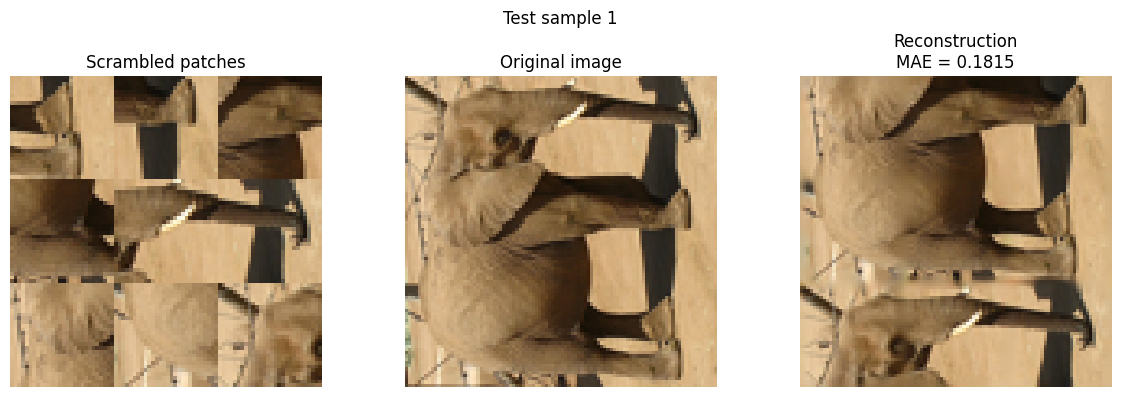

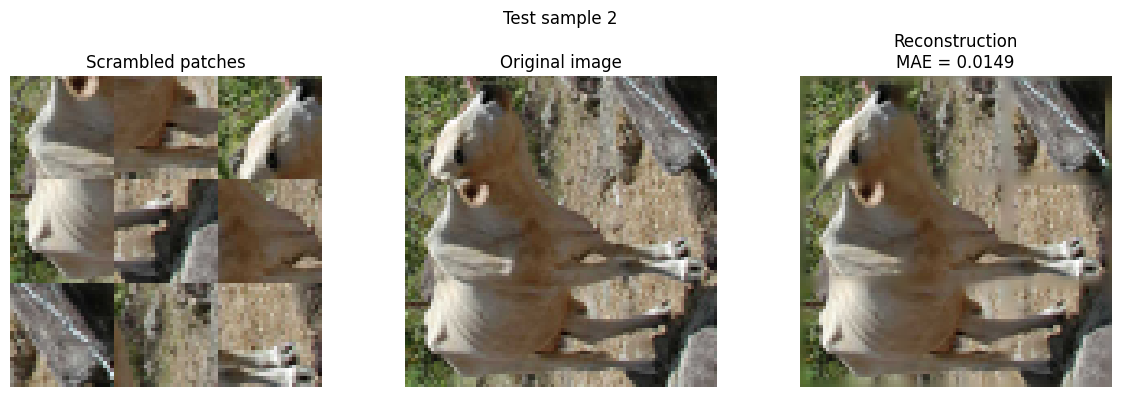

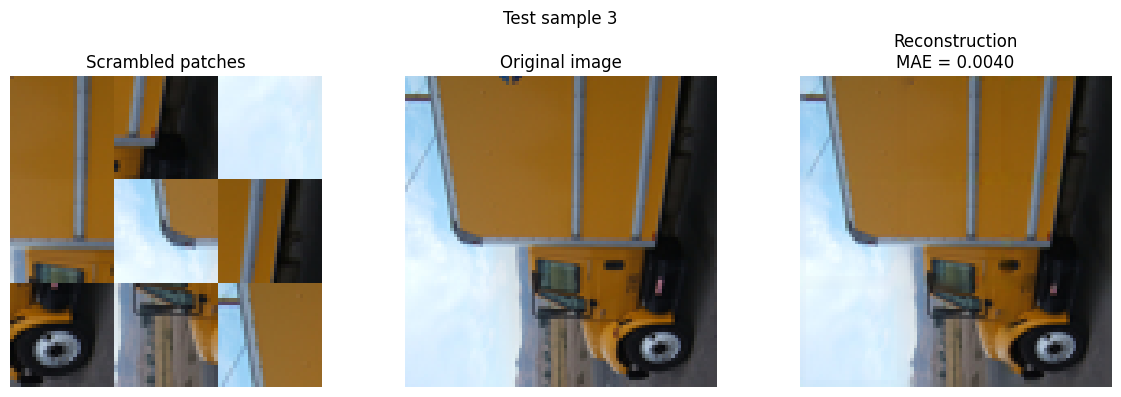

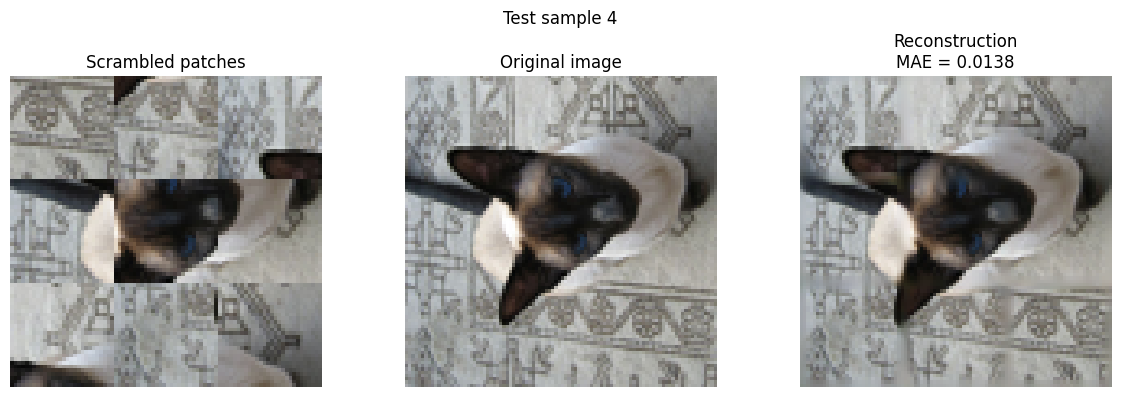

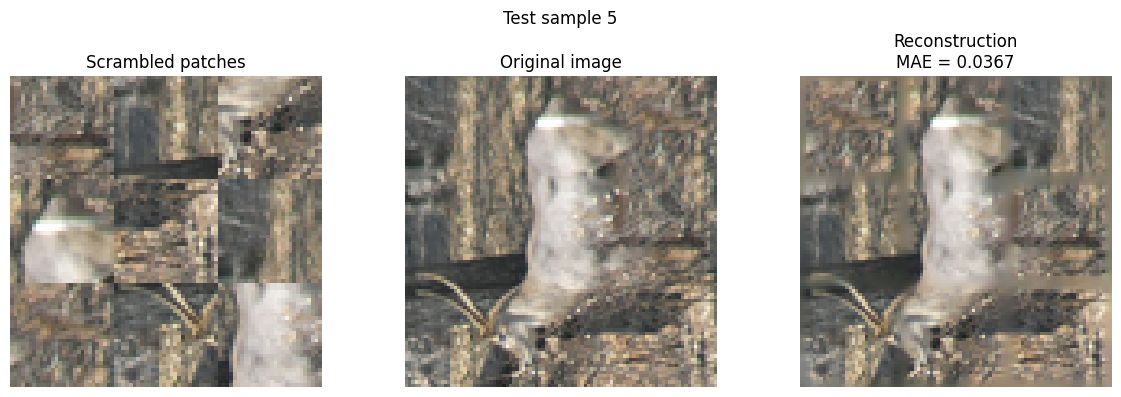

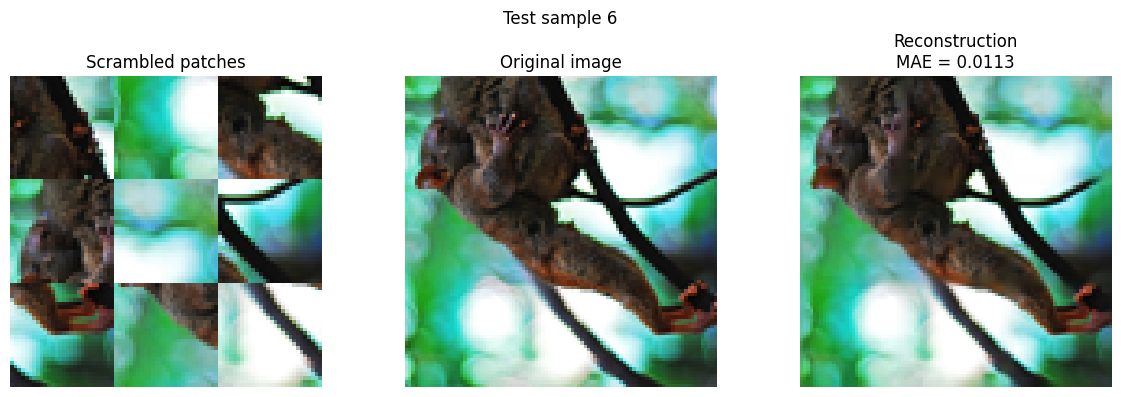

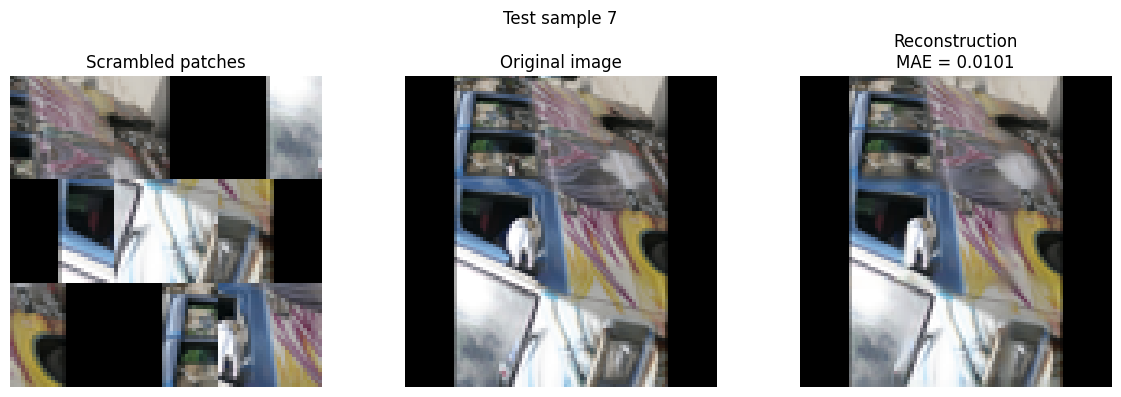

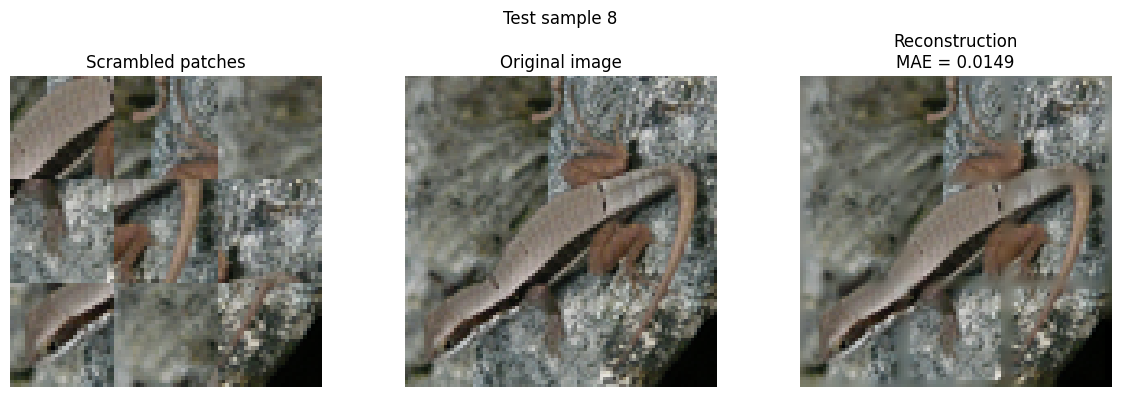

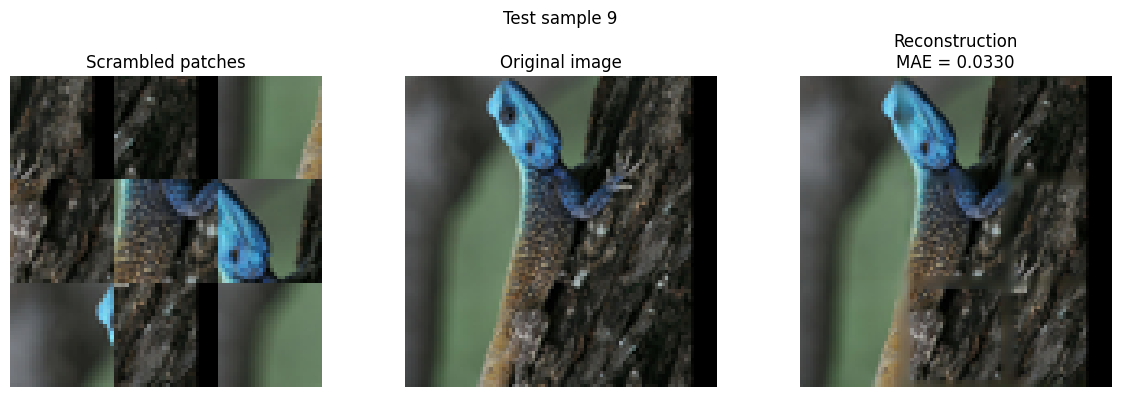

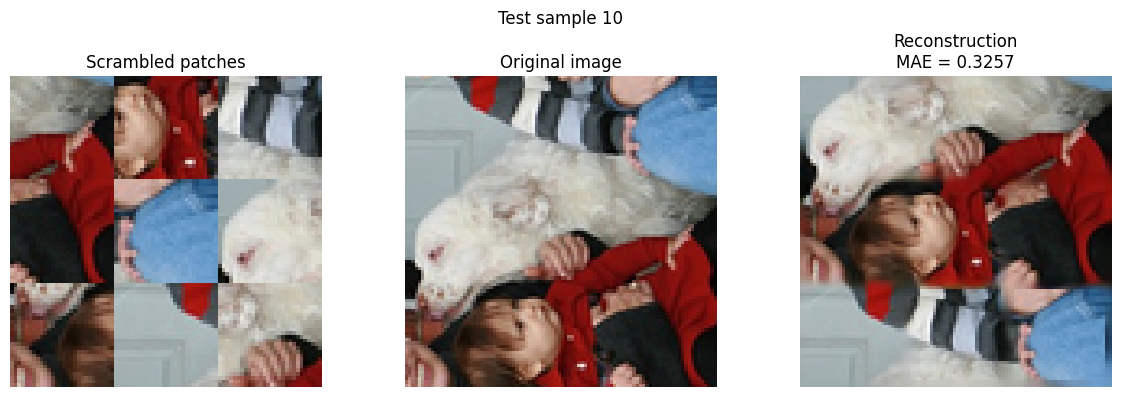

In [12]:
def show_predictions(model, generator, n=5, seed=SEED):
    np.random.seed(69)

    X, Y = generator[np.random.randint(len(generator))]
    pred = model.predict(X, verbose=0)

    selected = np.random.choice(len(X), size=min(n, len(X)), replace=False)

    for number, idx in enumerate(selected, start=1):
        sample_mae = np.mean(np.abs(pred[idx] - Y[idx]))

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(np.clip(make_puzzle_canvas(X[idx]), 0, 1))
        plt.title("Scrambled patches")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(np.clip(Y[idx], 0, 1))
        plt.title("Original image")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(np.clip(pred[idx], 0, 1))
        plt.title(f"Reconstruction\nMAE = {sample_mae:.4f}")
        plt.axis("off")

        plt.suptitle(f"Test sample {number}")
        plt.tight_layout()
        plt.show()


show_predictions(model, test_generator, n=10)


## Final reported result

Using the saved weights from the completed training run:

- Training session took about 2 hours
- Google Colab A100 GPU utilized
- Best validation loss was restored from epoch 40.
- Test MAE over the test generator: **0.035118**.
- Standard deviation of batch MAE values: **0.006101**.
- Total parameters: **4,203,013**.
- Trainable parameters: **4,198,980**.
